# Credit Risk Prediction Pipeline (XGBoost Only)

XGBoost multiclass classification for credit rating prediction.

**Architecture:**
- Train (original) → Optuna XGB (balanced weights)
- → Validation (real data) → Calibration (CV-based)
- → Test evaluation → SHAP on final model

**Optimizations applied:**
1. Winsorization (outlier clipping at 1st/99th pct)
2. 4-class target (Investment_High, Investment_Low, Speculative, Distressed)
3. Feature interaction engineering (composite ratios + log transforms)
4. More training data (CV-based calibration, no separate cal set)
5. Refined Optuna search (100 trials, narrowed ranges)
6. Post-hoc threshold optimization for macro F1

**Key design decisions:**
- Winsorization bounds computed on training data only (leakage-free)
- Sigmoid calibration via CV on full training set
- TreeExplainer for exact SHAP (calibration is monotonic)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
try:
    from sklearn.frozen import FrozenEstimator
    HAS_FROZEN_ESTIMATOR = True
except ImportError:
    HAS_FROZEN_ESTIMATOR = False
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    balanced_accuracy_score, confusion_matrix, roc_auc_score,
)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from scipy.optimize import minimize

import optuna
from optuna.integration import XGBoostPruningCallback

In [2]:
# CONFIGURATION

RANDOM_STATE = 42
N_OPTUNA_TRIALS = 30           # Reduced from 100 for speed (TPE converges fast)
N_CV_FOLDS = 3                 # Reduced from 5 for speed (faster, still robust)
TEST_SIZE = 0.2
VAL_SIZE = 0.15                # fraction of training data held out for early stopping
N_BOOTSTRAP = 500              # 500 bootstrap iterations (sufficient for 95% CI)
EARLY_STOPPING_ROUNDS = 50     # 50 rounds (converges fast enough)
USE_SMOTE = False              # False = balanced class weights (industry standard)
WINSORIZE_LOWER = 1            # Percentile for lower bound clipping
WINSORIZE_UPPER = 99           # Percentile for upper bound clipping

REPO_ROOT = Path.cwd()
DATA_PATH = REPO_ROOT / r"C:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\set A corporate_rating.csv"
FIG_DIR = REPO_ROOT / "python_models" / "xgboost_stuff" / "figures"
RESULTS_DIR = REPO_ROOT / "python_models" / "xgboost_stuff" / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"
print("Forced to CPU - faster for small datasets")


Forced to CPU - faster for small datasets


In [3]:
# CUSTOM LABEL ENCODER FOR STABLE COST MATRIX INDEX MAPPING

class ExplicitLabelEncoder:
    """Explicitly encode labels to map to a strict semantic order.
    
    Prevents silent indexing mismatches between model targets and cost matrices.
    """
    def __init__(self, mapping):
        self.mapping = mapping
        self.classes_ = np.array([c for c, _ in sorted(mapping.items(), key=lambda x: x[1])])
        
    def fit_transform(self, y):
        return np.array([self.mapping[val] for val in y])
        
    def transform(self, y):
        return np.array([self.mapping[val] for val in y])
        
    def inverse_transform(self, y):
        return np.array([self.classes_[val] for val in y])

In [4]:
# 1. DATA LOADING & PREPROCESSING

if DATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Drop columns that cause data leakage or carry no predictive signal
# Name/Symbol = company identity, Rating Agency/Date = metadata
df.drop(columns=["Name", "Symbol", "Rating Agency Name", "Date"], inplace=True)

# 2. TARGET ENGINEERING (4-CLASS: Investment_High, Investment_Low, Speculative, Distressed)

def collapse_rating(r):
    """Collapse granular credit ratings into 4 financial risk tiers.

    Investment_High : AAA, AA, A
    Investment_Low  : BBB
    Speculative     : BB, B, CCC, CC
    Distressed      : C, D
    """
    if r in ["AAA", "AA", "A"]:
        return "Investment_High"
    elif r in ["BBB"]:
        return "Investment_Low"
    elif r in ["BB", "B", "CCC", "CC"]:
        return "Speculative"
    else:
        return "Distressed"

df["RatingClass"] = df["Rating"].apply(collapse_rating)
df.drop(columns=["Rating"], inplace=True)

le = ExplicitLabelEncoder({
    "Investment_High": 0,
    "Investment_Low": 1,
    "Speculative": 2,
    "Distressed": 3,
})
y = le.fit_transform(df["RatingClass"])
X = df.drop(columns=["RatingClass"])

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {dict(zip(le.classes_, np.bincount(y)))}\n")

# 3. TRAIN / TEST SPLIT
# Test set is held out and NEVER touched until final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {len(y_train)} samples | Test: {len(y_test)} samples (held out)")

Dataset: 2029 samples, 26 features
Classes: {np.str_('Investment_High'): np.int64(494), np.str_('Investment_Low'): np.int64(671), np.str_('Speculative'): np.int64(861), np.str_('Distressed'): np.int64(3)}

Train: 1623 samples | Test: 406 samples (held out)


In [5]:
# 3.5 WINSORIZATION (LEAKAGE-FREE OUTLIER CLIPPING)

def winsorize_features(X_fit, X_target, bounds=None, lower_pct=1, upper_pct=99):
    """Clip extreme outliers using training-set percentiles (leakage-free)."""
    if bounds is None:
        numerics = X_fit.select_dtypes(include='number').columns
        bounds = {
            "lower": X_fit[numerics].quantile(lower_pct / 100.0),
            "upper": X_fit[numerics].quantile(upper_pct / 100.0),
        }
    
    X_out = X_target.copy()
    numerics_target = [c for c in X_out.select_dtypes(include='number').columns if c in bounds["lower"].index]
    
    if numerics_target:
        X_out[numerics_target] = X_out[numerics_target].clip(
            lower=bounds["lower"][numerics_target], 
            upper=bounds["upper"][numerics_target], 
            axis=1
        )
    return X_out, bounds

# 3.6 LEAKAGE-FREE FEATURE ENGINEERING FUNCTION

def add_zscore_features(X_fit, X_target, sector_stats=None):
    """Calculate and apply leakage-free sector-adjusted z-scores."""
    if sector_stats is None:
        ratios = [c for c in X_fit.columns if c not in ["Sector"] and not c.startswith("Sector_")]
        means = X_fit.groupby("Sector")[ratios].mean()
        stds = X_fit.groupby("Sector")[ratios].std().fillna(1.0)
        global_means = X_fit[ratios].mean()
        global_stds = X_fit[ratios].std().fillna(1.0)
        
        sector_stats = {
            "means": means,
            "stds": stds,
            "global_means": global_means,
            "global_stds": global_stds,
            "ratios": ratios,
        }
    else:
        ratios = sector_stats.get("ratios", list(sector_stats["global_means"].keys()))
    
    X_out = X_target.copy()
    
    # Fast vectorized mapping using merge
    if "Sector" in X_out.columns:
        m_sec = X_out[["Sector"]].merge(sector_stats["means"], left_on="Sector", right_index=True, how="left").drop(columns=["Sector"])
        s_sec = X_out[["Sector"]].merge(sector_stats["stds"], left_on="Sector", right_index=True, how="left").drop(columns=["Sector"])
        
        m_sec = m_sec.fillna(sector_stats["global_means"])
        s_sec = s_sec.fillna(sector_stats["global_stds"])
        
        z_scores = (X_out[ratios] - m_sec) / (s_sec + 1e-5)
        z_scores.columns = [f"{r}_sec_z" for r in ratios]
        
        X_out = pd.concat([X_out, z_scores], axis=1)
    
    return X_out, sector_stats

# 3.7 FEATURE INTERACTION ENGINEERING

def add_interaction_features(X):
    """Add domain-specific composite financial ratio features."""
    X_out = X.copy()
    
    # --- Composite ratio interactions ---
    X_out["leverage_coverage"] = (X_out["debtEquityRatio"] / (X_out["operatingProfitMargin"].abs() + 1e-5)).clip(-1e6, 1e6)
    X_out["liquidity_score"] = (X_out["currentRatio"] + X_out["quickRatio"] + X_out["cashRatio"]) / 3.0
    X_out["cashflow_debt_coverage"] = (X_out["operatingCashFlowPerShare"] / (X_out["debtEquityRatio"].abs() + 1e-5)).clip(-1e6, 1e6)
    X_out["profitability_composite"] = (X_out["netProfitMargin"] + X_out["operatingProfitMargin"] + X_out["grossProfitMargin"]) / 3.0
    X_out["debt_service_ratio"] = (X_out["operatingCashFlowSalesRatio"] / (X_out["debtRatio"] + 1e-5)).clip(-1e6, 1e6)
    X_out["efficiency_composite"] = (X_out["assetTurnover"] + X_out["fixedAssetTurnover"]) / 2.0

    # --- Additional interaction features for accuracy ---
    X_out["roa_leverage"] = (X_out["returnOnAssets"] / (X_out["debtRatio"] + 1e-5)).clip(-1e6, 1e6)
    X_out["margin_stability"] = (X_out["grossProfitMargin"] - X_out["netProfitMargin"]).abs()
    X_out["cash_liquidity_ratio"] = (X_out["cashRatio"] / (X_out["currentRatio"] + 1e-5)).clip(-1e6, 1e6)
    X_out["equity_efficiency"] = (X_out["returnOnCapitalEmployed"] * X_out["assetTurnover"]).clip(-1e6, 1e6)
    
    # --- Log transforms for highly skewed features ---
    skew_candidates = [
        "currentRatio", "quickRatio", "cashRatio", "daysOfSalesOutstanding",
        "debtEquityRatio", "enterpriseValueMultiple", "operatingCashFlowPerShare",
        "freeCashFlowPerShare", "cashPerShare", "payablesTurnover",
        "fixedAssetTurnover", "companyEquityMultiplier",
    ]
    cols_to_log = [c for c in skew_candidates if c in X_out.columns]
    if cols_to_log:
        for col in cols_to_log:
            X_out[f"{col}_log"] = np.sign(X_out[col]) * np.log1p(np.abs(X_out[col]))
            
    return X_out

# 4. SAFE SMOTE APPLICATION

def apply_smote(X_data, y_data):
    """Apply SMOTE with safety handling for extremely rare classes."""
    counts = pd.Series(y_data).value_counts()
    ros_targets = {c: 6 for c, n in counts.items() if n < 6}
    if ros_targets:
        X_data, y_data = RandomOverSampler(
            sampling_strategy=ros_targets, random_state=RANDOM_STATE,
        ).fit_resample(X_data, y_data)
    return SMOTE(random_state=RANDOM_STATE).fit_resample(X_data, y_data)

# 5. FULL FEATURE PIPELINE FUNCTION

def full_feature_pipeline(X_fit, X_target, pipeline_state=None):
    """Apply complete feature pipeline: winsorize -> interactions -> z-scores -> encode."""
    if pipeline_state is None:
        X_fit_w, w_bounds = winsorize_features(X_fit, X_fit, lower_pct=WINSORIZE_LOWER, upper_pct=WINSORIZE_UPPER)
        X_target_w, _ = winsorize_features(None, X_target, bounds=w_bounds)
        
        X_fit_i = add_interaction_features(X_fit_w)
        X_target_i = add_interaction_features(X_target_w)
        
        X_fit_z, sector_stats = add_zscore_features(X_fit_i, X_fit_i)
        X_target_z, _ = add_zscore_features(None, X_target_i, sector_stats)
        
        X_fit_enc = pd.get_dummies(X_fit_z, columns=["Sector"])
        X_target_enc = pd.get_dummies(X_target_z, columns=["Sector"])
        X_target_enc = X_target_enc.reindex(columns=X_fit_enc.columns, fill_value=0)
        
        pipeline_state = {
            "w_bounds": w_bounds,
            "sector_stats": sector_stats,
            "feature_columns": X_fit_enc.columns.tolist(),
        }
        return X_fit_enc, X_target_enc, pipeline_state
    else:
        X_target_w, _ = winsorize_features(None, X_target, bounds=pipeline_state["w_bounds"])
        X_target_i = add_interaction_features(X_target_w)
        X_target_z, _ = add_zscore_features(None, X_target_i, pipeline_state["sector_stats"])
        X_target_enc = pd.get_dummies(X_target_z, columns=["Sector"])
        X_target_enc = X_target_enc.reindex(columns=pipeline_state["feature_columns"], fill_value=0)
        return X_target_enc, pipeline_state

In [6]:
# 6. OPTUNA HYPERPARAMETER OPTIMIZATION

cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    """Optuna objective: 3-fold stratified CV with full feature pipeline."""
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 2000),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel":trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 7),
        "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 0.1, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
        "max_delta_step":   trial.suggest_int("max_delta_step", 0, 3),
        "objective":        "multi:softprob",
        "num_class":        len(le.classes_),
        "eval_metric":      "mlogloss",
        "device":           DEVICE,
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
    }

    scores = []
    pruning_callback = XGBoostPruningCallback(trial, "validation_0-mlogloss")
    
    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        X_tr_enc, X_val_enc, _ = full_feature_pipeline(X_tr, X_val)

        if USE_SMOTE:
            X_tr_res, y_tr_res = apply_smote(X_tr_enc, y_tr)
            sample_weight = None
        else:
            X_tr_res, y_tr_res = X_tr_enc, y_tr
            sample_weight = compute_sample_weight(class_weight="balanced", y=y_tr)

        callbacks = [pruning_callback] if fold_idx == 0 else None
        
        model = XGBClassifier(**params, early_stopping_rounds=EARLY_STOPPING_ROUNDS, callbacks=callbacks)
        model.fit(
            X_tr_res, y_tr_res, 
            eval_set=[(X_val_enc, y_val)], 
            sample_weight=sample_weight, 
            verbose=False
        )

        scores.append(f1_score(y_val, model.predict(X_val_enc), average="macro"))

    return np.mean(scores)

print("=" * 60)
print(f"OPTUNA HYPERPARAMETER OPTIMIZATION ({N_OPTUNA_TRIALS} trials, {N_CV_FOLDS}-fold CV)")
print("=" * 60)

def optuna_callback(study, trial):
    print(f"Trial {trial.number + 1}/{N_OPTUNA_TRIALS} completed | Value (Macro F1): {trial.value:.4f} | Best Value: {study.best_value:.4f}")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, callbacks=[optuna_callback])

print(f"\nBest CV Macro F1: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

OPTUNA HYPERPARAMETER OPTIMIZATION (30 trials, 3-fold CV)
Trial 1/30 completed | Value (Macro F1): 0.5517 | Best Value: 0.5517
Trial 2/30 completed | Value (Macro F1): 0.5411 | Best Value: 0.5517
Trial 3/30 completed | Value (Macro F1): 0.5492 | Best Value: 0.5517
Trial 4/30 completed | Value (Macro F1): 0.5446 | Best Value: 0.5517
Trial 5/30 completed | Value (Macro F1): 0.5403 | Best Value: 0.5517
Trial 6/30 completed | Value (Macro F1): 0.5368 | Best Value: 0.5517
Trial 7/30 completed | Value (Macro F1): 0.5282 | Best Value: 0.5517
Trial 8/30 completed | Value (Macro F1): 0.5492 | Best Value: 0.5517
Trial 9/30 completed | Value (Macro F1): 0.5565 | Best Value: 0.5565
Trial 10/30 completed | Value (Macro F1): 0.5435 | Best Value: 0.5565
Trial 11/30 completed | Value (Macro F1): 0.8790 | Best Value: 0.5565
Trial 12/30 completed | Value (Macro F1): 0.5406 | Best Value: 0.5565
Trial 13/30 completed | Value (Macro F1): 0.5420 | Best Value: 0.5565
Trial 14/30 completed | Value (Macro F1):

In [7]:
# 7. FINAL MODEL TRAINING

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_fit_enc, X_val_enc, pipeline_state = full_feature_pipeline(X_fit, X_val)
X_test_enc, _ = full_feature_pipeline(None, X_test, pipeline_state=pipeline_state)

# Save pipeline state
import joblib
joblib.dump(pipeline_state["sector_stats"], RESULTS_DIR / "sector_stats.pkl")
joblib.dump(pipeline_state["w_bounds"], RESULTS_DIR / "winsorize_bounds.pkl")
joblib.dump(pipeline_state["feature_columns"], RESULTS_DIR / "feature_columns.pkl")
print(f"Pipeline state saved to: {RESULTS_DIR}")

if USE_SMOTE:
    X_fit_res, y_fit_res = apply_smote(X_fit_enc, y_fit)
    sample_weight_fit = None
else:
    X_fit_res, y_fit_res = X_fit_enc, y_fit
    sample_weight_fit = compute_sample_weight(class_weight="balanced", y=y_fit)

xgb_model = XGBClassifier(
    **study.best_params,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    device=DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)
xgb_model.fit(X_fit_res, y_fit_res, eval_set=[(X_val_enc, y_val)], sample_weight=sample_weight_fit, verbose=False)

print(f"\nFinal XGBoost trained (best_iteration={xgb_model.best_iteration})")

# 8. PROBABILITY CALIBRATION (CV-BASED)

X_train_enc_full, X_test_enc_full, pipeline_state_full = full_feature_pipeline(X_train, X_test)

if USE_SMOTE:
    sample_weight_cal = None
else:
    sample_weight_cal = compute_sample_weight(class_weight="balanced", y=y_train)

xgb_for_cal = XGBClassifier(
    **study.best_params,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    device=DEVICE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

calibrated_model = CalibratedClassifierCV(
    estimator=xgb_for_cal,
    method="sigmoid",
    cv=2,
)
calibrated_model.fit(X_train_enc_full, y_train, sample_weight=sample_weight_cal)
print("Calibration complete (sigmoid, 2-fold CV on full training set)")

# Update pipeline state with full training stats
joblib.dump(pipeline_state_full["sector_stats"], RESULTS_DIR / "sector_stats.pkl")
joblib.dump(pipeline_state_full["w_bounds"], RESULTS_DIR / "winsorize_bounds.pkl")
joblib.dump(pipeline_state_full["feature_columns"], RESULTS_DIR / "feature_columns.pkl")

Pipeline state saved to: c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results

Final XGBoost trained (best_iteration=1429)
Calibration complete (sigmoid, 2-fold CV on full training set)


['c:\\Users\\24042662\\Desktop\\N word\\Credit-Risk-Analyzer\\python_models\\xgboost_stuff\\results\\feature_columns.pkl']

In [8]:
# 9. THRESHOLD OPTIMIZATION (POST-HOC)

def optimize_thresholds(y_true, y_proba, n_classes):
    """Find optimal per-class probability scaling factors that maximize macro F1."""
    def neg_f1(thresholds):
        adjusted = y_proba * thresholds
        preds = adjusted.argmax(axis=1)
        return -f1_score(y_true, preds, average='macro')
    
    best_score = -1
    best_thresholds = np.ones(n_classes)
    
    for _ in range(10):  # 10 restarts (sufficient for convergence)
        init = np.random.uniform(0.5, 2.0, n_classes)
        result = minimize(neg_f1, init, method='Nelder-Mead',
                         options={'maxiter': 1000, 'xatol': 1e-4, 'fatol': 1e-4})
        if -result.fun > best_score:
            best_score = -result.fun
            best_thresholds = result.x
    
    best_thresholds = best_thresholds / best_thresholds.sum() * n_classes
    return best_thresholds

# Learn thresholds on validation set (not test set!)
X_val_enc_full, _ = full_feature_pipeline(None, X_val, pipeline_state=pipeline_state_full)
y_val_proba = calibrated_model.predict_proba(X_val_enc_full)
optimal_thresholds = optimize_thresholds(y_val, y_val_proba, len(le.classes_))
print(f"\nOptimal thresholds: {dict(zip(le.classes_, optimal_thresholds))}")


Optimal thresholds: {np.str_('Investment_High'): np.float64(1.0376464441929103), np.str_('Investment_Low'): np.float64(0.8444223880903798), np.str_('Speculative'): np.float64(1.5335150575334011), np.str_('Distressed'): np.float64(0.5844161101833089)}


In [9]:
# 10. TEST SET EVALUATION

y_proba = calibrated_model.predict_proba(X_test_enc_full)
y_pred_standard = calibrated_model.predict(X_test_enc_full)

# Apply threshold-optimized predictions
y_proba_adjusted = y_proba * optimal_thresholds
y_pred_threshold = y_proba_adjusted.argmax(axis=1)

# Choose the better prediction set
f1_standard = f1_score(y_test, y_pred_standard, average="macro")
f1_threshold = f1_score(y_test, y_pred_threshold, average="macro")

if f1_threshold > f1_standard:
    y_pred = y_pred_threshold
    use_thresholds = True
    print(f"\nThreshold optimization improved Macro F1: {f1_standard:.4f} -> {f1_threshold:.4f}")
else:
    y_pred = y_pred_standard
    use_thresholds = False
    print(f"\nStandard predictions used (threshold F1 {f1_threshold:.4f} <= standard {f1_standard:.4f})")

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
bal_acc = balanced_accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro",
)

print("\n" + "=" * 60)
print("TEST SET RESULTS (XGBoost Calibrated)")
print("=" * 60)
print(f"Accuracy:          {acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"ROC-AUC (OVR):     {roc_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")

# Use XGBoost predictions for all downstream evaluation
best_pred = y_pred
best_proba = y_proba
best_f1 = macro_f1
best_acc = acc
best_bal = bal_acc
best_auc = roc_auc


Threshold optimization improved Macro F1: 0.4749 -> 0.4924

TEST SET RESULTS (XGBoost Calibrated)
Accuracy:          0.6675
Macro F1:          0.4924
Balanced Accuracy: 0.4959
ROC-AUC (OVR):     0.8637

                 precision    recall  f1-score   support

Investment_High       0.63      0.70      0.66        99
 Investment_Low       0.55      0.51      0.53       134
    Speculative       0.78      0.78      0.78       172
     Distressed       0.00      0.00      0.00         1

       accuracy                           0.67       406
      macro avg       0.49      0.50      0.49       406
   weighted avg       0.67      0.67      0.67       406



In [10]:
# 11. FEATURE IMPORTANCE (SHAP MEAN ABSOLUTE VALUES)

import shap

print("\n" + "=" * 60)
print("COMPUTING SHAP VALUES (TreeExplainer)")
print("=" * 60)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_enc_full)

if isinstance(shap_values, list):
    mean_abs_per_class = [np.abs(val).mean(axis=0) for val in shap_values]
    shap_importance = np.mean(mean_abs_per_class, axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=(0, 2))

importance = pd.DataFrame({
    "feature": X_test_enc_full.columns,
    "importance": shap_importance,
}).sort_values("importance", ascending=False)

print(f"Top 15 Features (SHAP Mean Absolute Values):\n{importance.head(15).to_string(index=False)}")

# 12. BOOTSTRAP CONFIDENCE INTERVALS

boot_scores = []
for _ in range(N_BOOTSTRAP):
    idx = resample(range(len(y_test)))
    boot_scores.append(f1_score(y_test[idx], best_pred[idx], average="macro"))

ci = np.percentile(boot_scores, [2.5, 97.5])
print(f"\n95% CI for Macro F1: [{ci[0]:.4f}, {ci[1]:.4f}]")

# 13. COST-SENSITIVE FINANCIAL EVALUATION (4-CLASS)

COST_MATRIX = np.array([
    # Pred:  Inv_H  Inv_L  Spec  Dist
    [         0,     1,     2,     3],   # Actual: Investment_High
    [         2,     0,     2,     3],   # Actual: Investment_Low
    [         5,     3,     0,     2],   # Actual: Speculative
    [        10,     7,     3,     0],   # Actual: Distressed
])

cm = confusion_matrix(y_test, best_pred)
total_cost = np.sum(cm * COST_MATRIX)

max_cost = np.sum(cm.sum(axis=1) * COST_MATRIX.max(axis=1))
efficiency = 1 - (total_cost / max_cost) if max_cost > 0 else 0.0

print(f"\n{'=' * 60}")
print("COST-SENSITIVE FINANCIAL EVALUATION")
print(f"{'=' * 60}")
print(f"Total Misclassification Cost:  {total_cost}")
print(f"Maximum Possible Cost:         {max_cost}")
print(f"Cost Efficiency:               {efficiency:.4f}")
print(f"\nCost Breakdown (actual x predicted):")
print(pd.DataFrame(
    cm * COST_MATRIX,
    index=[f"Act:{c}" for c in le.classes_],
    columns=[f"Pred:{c}" for c in le.classes_],
))


COMPUTING SHAP VALUES (TreeExplainer)
Top 15 Features (SHAP Mean Absolute Values):
                          feature  importance
                  debtRatio_sec_z    0.421797
        debtEquityRatio_log_sec_z    0.236102
             returnOnAssets_sec_z    0.171018
          leverage_coverage_sec_z    0.147582
companyEquityMultiplier_log_sec_z    0.110466
           cashflow_debt_coverage    0.109940
                        debtRatio    0.108875
            debtEquityRatio_sec_z    0.105955
               currentRatio_sec_z    0.084873
          returnOnCapitalEmployed    0.069779
                 effectiveTaxRate    0.066703
    companyEquityMultiplier_sec_z    0.060880
        operatingCashFlowPerShare    0.058636
            netProfitMargin_sec_z    0.055295
          enterpriseValueMultiple    0.053985

95% CI for Macro F1: [0.4571, 0.6895]

COST-SENSITIVE FINANCIAL EVALUATION
Total Misclassification Cost:  297
Maximum Possible Cost:         1569
Cost Efficiency:               0.

In [11]:
# 14. PREDICTION API READINESS

def predict_risk(input_df):
    """Predict credit risk categories and calibrated probabilities for new input data."""
    df_in = input_df.copy()
    drop_cols = ["Name", "Symbol", "Rating Agency Name", "Date", "RatingClass", "Rating"]
    df_in = df_in.drop(columns=[c for c in drop_cols if c in df_in.columns], errors="ignore")
    
    import joblib
    stats = joblib.load(RESULTS_DIR / "sector_stats.pkl")
    w_bounds = joblib.load(RESULTS_DIR / "winsorize_bounds.pkl")
    feature_cols = joblib.load(RESULTS_DIR / "feature_columns.pkl")
    
    ps = {
        "sector_stats": stats,
        "w_bounds": w_bounds,
        "feature_columns": feature_cols,
    }
    
    df_in_enc, _ = full_feature_pipeline(None, df_in, pipeline_state=ps)
    
    proba = calibrated_model.predict_proba(df_in_enc)
    pred = calibrated_model.predict(df_in_enc)

    strategy_path = RESULTS_DIR / "prediction_strategy.pkl"
    strategy = joblib.load(strategy_path) if strategy_path.exists() else {"use_thresholds": use_thresholds}
    optimal_thresholds = joblib.load(RESULTS_DIR / "optimal_thresholds.pkl")

    if strategy.get("use_thresholds"):
        adjusted = proba * optimal_thresholds
        pred_indices = adjusted.argmax(axis=1)
    else:
        pred_indices = pred

    pred_labels = le.inverse_transform(pred_indices)
    return pred_labels, proba

# Example test prediction using the first 5 samples from the test set
test_samples = X_test.head(5)
test_preds, test_probas = predict_risk(test_samples)
print("\n" + "=" * 60)
print("PREDICTION API READINESS TEST (First 5 Test Samples)")
print("=" * 60)
for idx, (label, prob) in enumerate(zip(test_preds, test_probas)):
    prob_str = ", ".join([f"{c}: {p:.4f}" for c, p in zip(le.classes_, prob)])
    print(f"Sample #{idx+1} -> Predicted: {label} | Probabilities: [{prob_str}]")


PREDICTION API READINESS TEST (First 5 Test Samples)
Sample #1 -> Predicted: Investment_Low | Probabilities: [Investment_High: 0.3223, Investment_Low: 0.3776, Speculative: 0.0925, Distressed: 0.2076]
Sample #2 -> Predicted: Speculative | Probabilities: [Investment_High: 0.0784, Investment_Low: 0.1586, Speculative: 0.5294, Distressed: 0.2336]
Sample #3 -> Predicted: Speculative | Probabilities: [Investment_High: 0.0740, Investment_Low: 0.1239, Speculative: 0.5903, Distressed: 0.2119]
Sample #4 -> Predicted: Investment_Low | Probabilities: [Investment_High: 0.0813, Investment_Low: 0.5210, Speculative: 0.1828, Distressed: 0.2149]
Sample #5 -> Predicted: Investment_High | Probabilities: [Investment_High: 0.6861, Investment_Low: 0.0954, Speculative: 0.0791, Distressed: 0.1394]


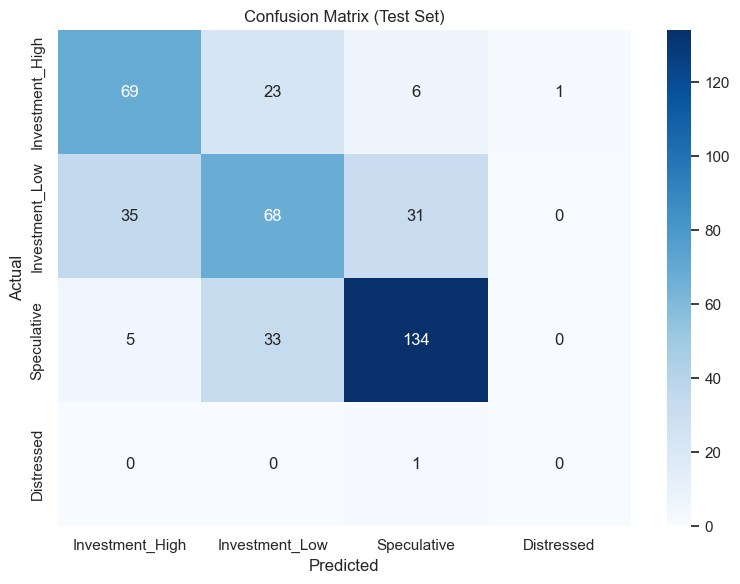

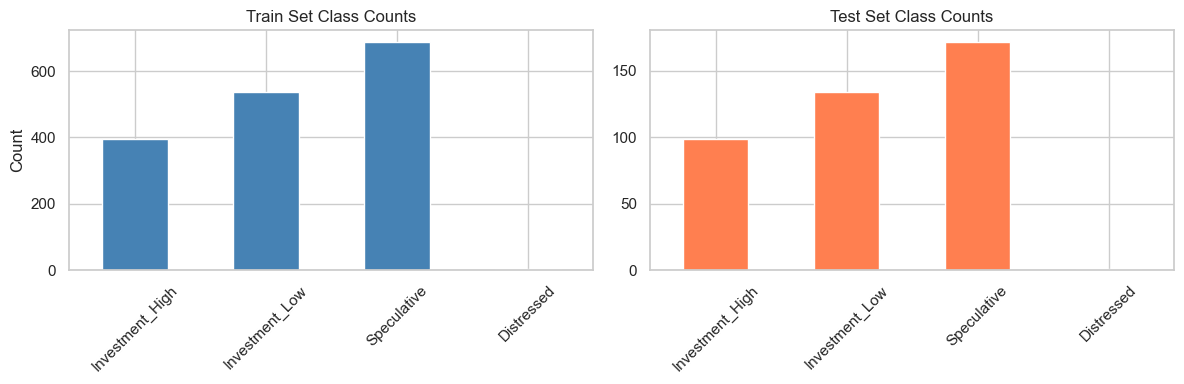

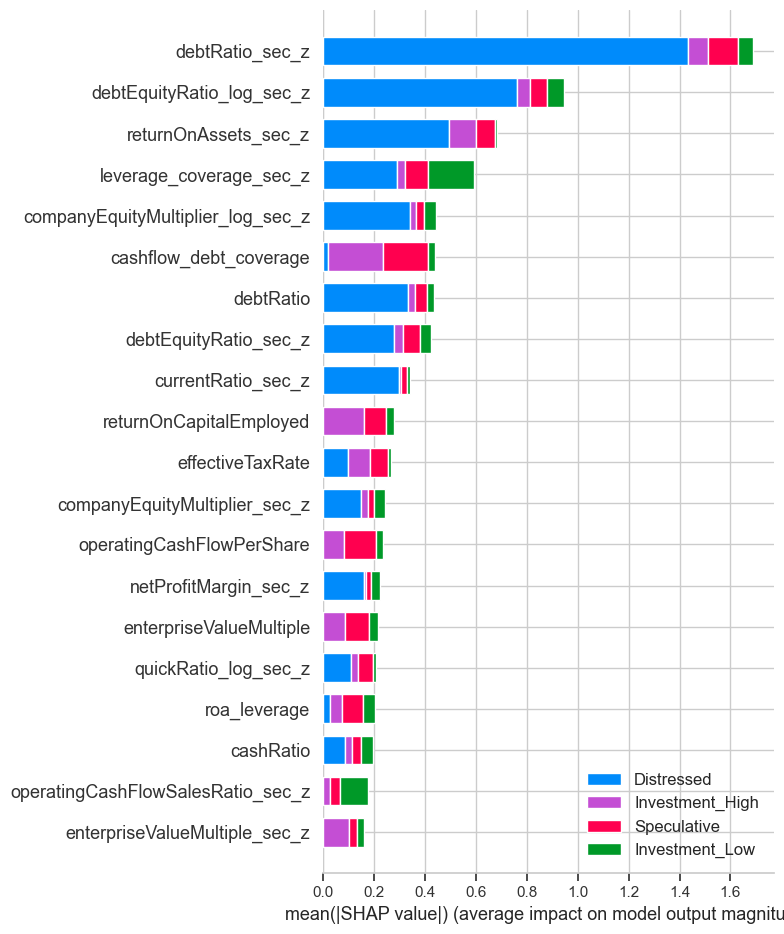

<Figure size 1000x600 with 0 Axes>

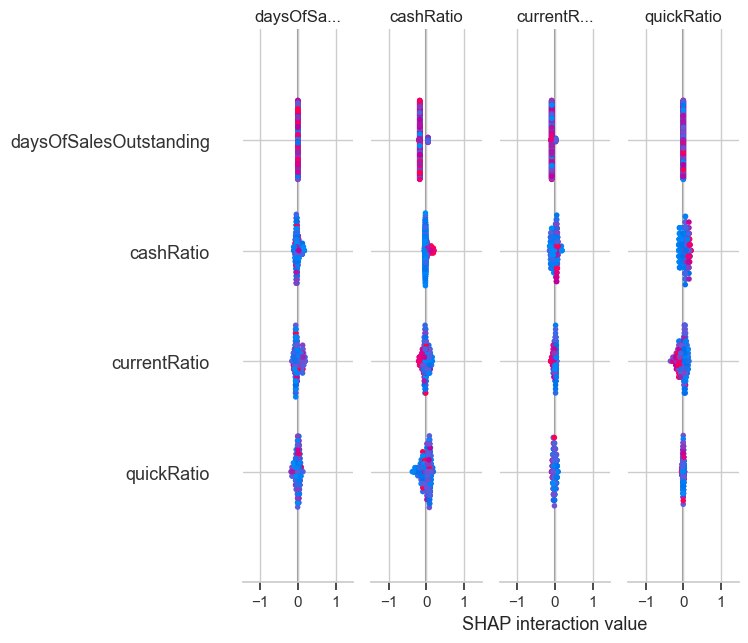


Company #0
Predicted: Investment_High
Actual:    Investment_High


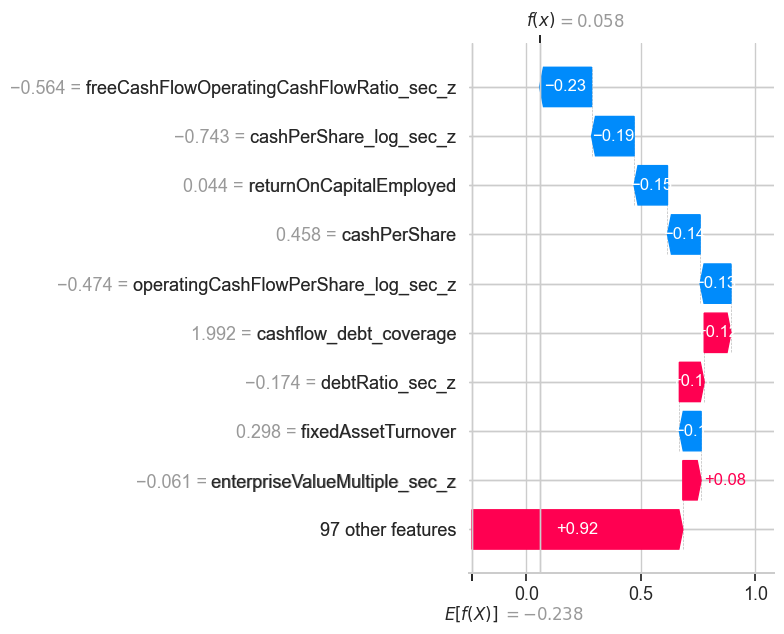

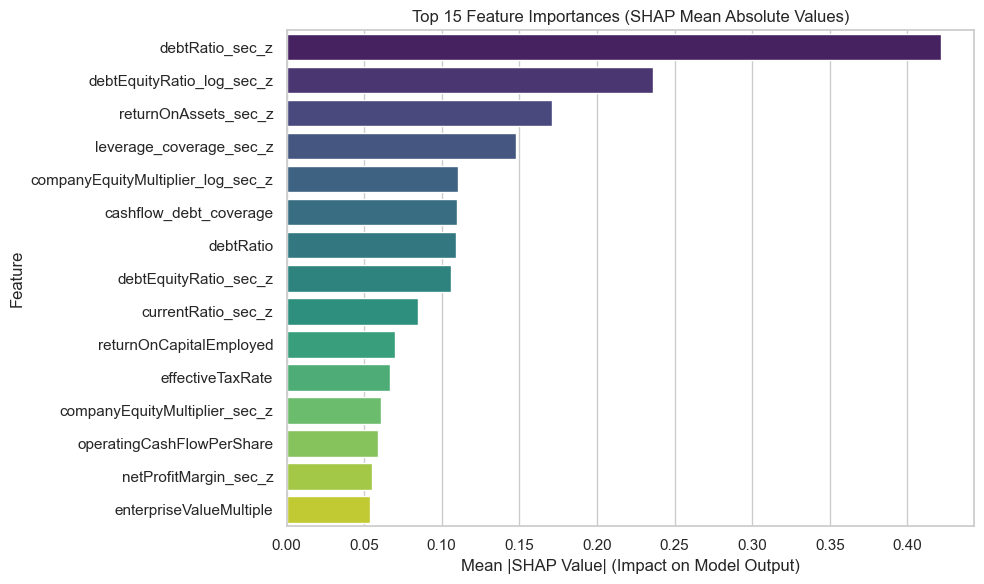


All figures saved to: c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\figures


In [12]:
# VISUALIZATIONS & EXPLAINABILITY

import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# -- 1. Confusion Matrix Heatmap --
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# -- 2. Class Distribution (Train vs Test) --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_map = dict(enumerate(le.classes_))

train_cts = pd.Series(y_train).map(class_map).value_counts().reindex(le.classes_, fill_value=0)
test_cts = pd.Series(y_test).map(class_map).value_counts().reindex(le.classes_, fill_value=0)

train_cts.plot(kind="bar", ax=axes[0], color="steelblue", rot=45)
axes[0].set_title("Train Set Class Counts")
axes[0].set_ylabel("Count")

test_cts.plot(kind="bar", ax=axes[1], color="coral", rot=45)
axes[1].set_title("Test Set Class Counts")

plt.tight_layout()
fig.savefig(FIG_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# -- 3. SHAP Explainability --
# Global feature importance (bar plot)
plt.figure()
shap.summary_plot(
    shap_values, X_test_enc_full, class_names=le.classes_,
    plot_type="bar", show=False,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm plot (all classes)
plt.figure()
shap.summary_plot(
    shap_values, X_test_enc_full, class_names=le.classes_, show=False,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Waterfall plot for a single company
company_index = 0
pred_class = int(best_pred[company_index])
print(f"\nCompany #{company_index}")
print(f"Predicted: {le.classes_[pred_class]}")
print(f"Actual:    {le.classes_[y_test[company_index]]}")

explanation = explainer(X_test_enc_full)
plt.figure()
shap.plots.waterfall(
    explanation[company_index, :, pred_class], show=False,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_waterfall_company0.png", dpi=150, bbox_inches="tight")
plt.show()

# -- 4. SHAP Global Feature Importance --
plt.figure(figsize=(10, 6))
sns.barplot(
    x="importance", y="feature",
    data=importance.head(15), palette="viridis",
)
plt.title("Top 15 Feature Importances (SHAP Mean Absolute Values)")
plt.xlabel("Mean |SHAP Value| (Impact on Model Output)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll figures saved to: {FIG_DIR}")

In [13]:
# SAVE RESULTS

import joblib
from sklearn.metrics import classification_report

# Save base and calibrated models
joblib.dump(xgb_model, RESULTS_DIR / "xgb_credit_model.pkl")
print(f"Base model saved to:        {RESULTS_DIR / 'xgb_credit_model.pkl'}")
joblib.dump(calibrated_model, RESULTS_DIR / "calibrated_model.pkl")
print(f"Calibrated model saved to:  {RESULTS_DIR / 'calibrated_model.pkl'}")

# Save evaluation metrics
metrics = {
    "accuracy": best_acc,
    "balanced_accuracy": best_bal,
    "f1_macro": best_f1,
    "roc_auc_ovr": best_auc,
}
with open(RESULTS_DIR / "xgboost_metrics.txt", "w") as f:
    f.write("XGBoost Model Evaluation Metrics (XGBoost Only)\n")
    f.write("-" * 40 + "\n")
    for name, val in metrics.items():
        f.write(f"{name}: {val:.4f}\n")
print(f"Metrics saved to:           {RESULTS_DIR / 'xgboost_metrics.txt'}")

# Save test predictions
pd.DataFrame({
    "actual": le.inverse_transform(y_test),
    "predicted": le.inverse_transform(best_pred),
}).to_csv(RESULTS_DIR / "xgboost_test_predictions.csv", index=False)
print(f"Predictions saved to:       {RESULTS_DIR / 'xgboost_test_predictions.csv'}")

# Save feature importances
importance.to_csv(RESULTS_DIR / "xgboost_feature_importance.csv", index=False)
print(f"Feature importances saved:  {RESULTS_DIR / 'xgboost_feature_importance.csv'}")

# Save classification report
report = pd.DataFrame(
    classification_report(y_test, best_pred, target_names=le.classes_, output_dict=True)
).transpose()
report.to_csv(RESULTS_DIR / "xgboost_classification_report.csv")
print(f"Classification report saved:{RESULTS_DIR / 'xgboost_classification_report.csv'}")

# Save optimal thresholds
joblib.dump(optimal_thresholds, RESULTS_DIR / "optimal_thresholds.pkl")
print(f"Optimal thresholds saved:   {RESULTS_DIR / 'optimal_thresholds.pkl'}")

joblib.dump({"use_thresholds": use_thresholds}, RESULTS_DIR / "prediction_strategy.pkl")
print(f"Prediction strategy saved:  {RESULTS_DIR / 'prediction_strategy.pkl'} (use_thresholds={use_thresholds})")

# Summary
print(f"\n{'=' * 40}")
print("Final Summary:")
for name, val in metrics.items():
    print(f"  {name:<20}: {val:.4f}")

Base model saved to:        c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\xgb_credit_model.pkl
Calibrated model saved to:  c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\calibrated_model.pkl
Metrics saved to:           c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\xgboost_metrics.txt
Predictions saved to:       c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\xgboost_test_predictions.csv
Feature importances saved:  c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\xgboost_feature_importance.csv
Classification report saved:c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\xgboost_classification_report.csv
Optimal thresholds saved:   c:\Users\24042662\Desktop\N word\Credit-Risk-Analyzer\python_models\xgboost_stuff\results\optimal_thresholds